# Smart Document Scanner + OCR
## Phase 1 - Traditional CV Pipeline

In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
import easyocr
os.environ["TESSDATA_PREFIX"] = "/usr/share/tessdata"


In [2]:
IMAGES_DIR = "../dataset/images"
OUTPUTS = {
    "original": "../outputs/original",
    "gray": "../outputs/gray",
    "blur": "../outputs/blur",
    "edges": "../outputs/edges",
    "contours": "../outputs/contours",
    "warp": "../outputs/warp",
    "clean": "../outputs/clean",
    "ocr": "../outputs/ocr_results",
}

for folder in OUTPUTS.values():
    os.makedirs(folder, exist_ok=True)

image_paths = sorted(glob.glob(f"{IMAGES_DIR}/test*.jpg"))
print(f"Found {len(image_paths)} images")
for p in image_paths:
    print("-", os.path.basename(p))


Found 1 images
- test1.jpg


In [3]:
def show(images, figsize=(16, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (title, img) in enumerate(images.items(), 1):
        plt.subplot(1, n, i)
        if len(img.shape) == 3:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(img, cmap="gray")
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def order_points(pts):
    pts = pts.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left
    rect[2] = pts[np.argmax(s)]   # bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left

    return rect


def preprocess_for_ocr(warped):
    gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)         # contrast
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, clean = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    clean = cv2.medianBlur(clean, 3)
    return clean


## Test one image and show all important steps

In [12]:
def process_image(image_path):
    name = os.path.splitext(os.path.basename(image_path))[0]

    img = cv2.imread(image_path)
    if img is None:
        return None

    cv2.imwrite(f"{OUTPUTS['original']}/{name}.jpg", img)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cv2.imwrite(f"{OUTPUTS['gray']}/{name}.jpg", gray)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    cv2.imwrite(f"{OUTPUTS['blur']}/{name}.jpg", blur)

    edges = cv2.Canny(blur, 50, 150)
    cv2.imwrite(f"{OUTPUTS['edges']}/{name}.jpg", edges)

    contours, _ = cv2.findContours(
        edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    document_contour = None
    for cnt in contours:
        if cv2.contourArea(cnt) < 1000:
            continue
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4:
            document_contour = approx
            break

    img_draw = img.copy()
    warped = None
    clean = None
    tess_text = ""
    easy_text = ""

    if document_contour is not None:
        cv2.drawContours(img_draw, [document_contour], -1, (0, 255, 0), 3)
        cv2.imwrite(f"{OUTPUTS['contours']}/{name}.jpg", img_draw)

        rect = order_points(document_contour)
        (tl, tr, br, bl) = rect

        widthA = np.linalg.norm(br - bl)
        widthB = np.linalg.norm(tr - tl)
        maxWidth = int(max(widthA, widthB))

        heightA = np.linalg.norm(tr - br)
        heightB = np.linalg.norm(tl - bl)
        maxHeight = int(max(heightA, heightB))

        dst = np.array([
            [0, 0],
            [maxWidth - 1, 0],
            [maxWidth - 1, maxHeight - 1],
            [0, maxHeight - 1]
        ], dtype="float32")

        M = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))
        cv2.imwrite(f"{OUTPUTS['warp']}/{name}.jpg", warped)

        clean = preprocess_for_ocr(warped)
        cv2.imwrite(f"{OUTPUTS['clean']}/{name}.jpg", clean)

        # Tesseract
        tess_text = pytesseract.image_to_string(
            clean,
            lang="fra",
            config="--psm 6"
        )

        with open(f"{OUTPUTS['ocr']}/{name}_tesseract.txt", "w", encoding="utf-8") as f:
            f.write(tess_text)

        # EasyOCR
        easy_result = reader.readtext(clean, detail=0, paragraph=True)
        easy_text = "\n".join(easy_result)

        with open(f"{OUTPUTS['ocr']}/{name}_easyocr.txt", "w", encoding="utf-8") as f:
            f.write(easy_text)

    return {
        "name": name,
        "img": img,
        "gray": gray,
        "blur": blur,
        "edges": edges,
        "contour_found": document_contour is not None,
        "contour_image": img_draw,
        "warped": warped,
        "clean": clean,
        "tess_text": tess_text,
        "easy_text": easy_text
    }

Image: test1
Contour found: True

OCR preview:

NUMIDIA INSTITUTE OF TECHNOLOGY ‘ ’y ,
Données Structurées ' 20Z5- uR, fS
2026 | __" ÉÉ L e
TD1 Trigger / PLSQL Ê,‘ 0 48
Exercice 1 As : « ° Le' Bws E :—…—Œ‘î ‘
; Les membres dirigeants d'une association d’une région se servent d'une b_a;se.degfdp,n_r@gg_g@\r me €ûﬁ.{, 7 -
; d'organiser la gestion des adhésions des membres (inscription des: m‘e‘m«b'rqs;ç_t;'c9_IÏIÊ_Ç_t@"' ' L - .
- cotisations annuelles) et l'organisation de leurs participations à des congrès..On propiose‘le<modèlé) - 05P5
relationnel suivant : ° ‘ ; .. .
| ‘ MEMBRES (NUMERO_MBR, NOM.MBR, DATE_ADHESION .MBR, ADRESSE_MBR) ‘ III aaaAAÇK >
CONGRES (CODE_CGN, THEME- CGN, PAYS_CGN, DUREE_CGN, NB_PARTICIPÀNT_CGN, s.. “ . 2
MONTANT_FIXE, L ‘ . u - AN
MONTANT_TOTAL COTISE) ‘ 1 E> « … * 22088
PARTICIPATIONS (NUMERO_MBR*, CODE_CGN*, MONTANT_COTISE) Exs 1 A
1. Créer les tables en respectant les contraintes d’intégrité structurelles. - {.'
2. Implémenterles contraintes ci-après : ; e

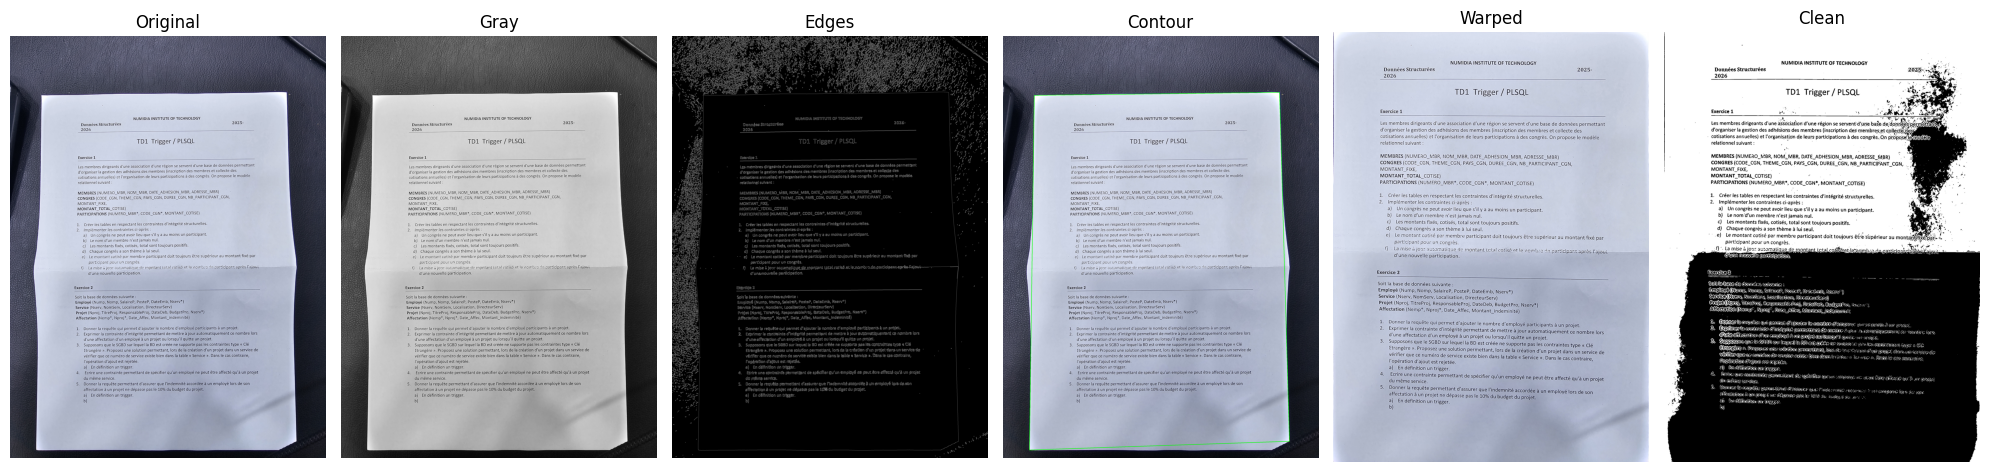

In [5]:
result = process_image(image_paths[0])

print("Image:", result["name"])
print("Contour found:", result["contour_found"])
print("\nOCR preview:\n")
print(result["tess_text"][:1200] if result["tess_text"] else "No OCR result")

images_to_show = {
    "Original": result["img"],
    "Gray": result["gray"],
    "Edges": result["edges"],
    "Contour": result["contour_image"],
}

if result["warped"] is not None:
    images_to_show["Warped"] = result["warped"]
if result["clean"] is not None:
    images_to_show["Clean"] = result["clean"]

show(images_to_show, figsize=(20, 5))


## Run all images

In [6]:
results = []

for path in image_paths:
    result = process_image(path)
    if result is not None:
        results.append(result)
        status = "OK" if result["contour_found"] else "Missing contour"
        print(f"{result['name']}: {status}")

print(f"\nProcessed {len(results)} images.")


test1: OK

Processed 1 images.


In [7]:
print(f"{'#':<4} {'Image':<12} {'Contour':<16} {'OCR Preview'}")
print("-" * 80)

for i, r in enumerate(results, 1):
    status = "Found" if r["contour_found"] else "Missing"
    preview = r["tess_text"][:40].replace("\n", " ") + "..." if r["tess_text"] else "No OCR"
    print(f"{i:<4} {r['name']:<12} {status:<16} {preview}")


#    Image        Contour          OCR Preview
--------------------------------------------------------------------------------
1    test1        Found            NUMIDIA INSTITUTE OF TECHNOLOGY ‘ ’y , D...


In [13]:
reader = easyocr.Reader(['fr', 'en'], gpu=False)

Using CPU. Note: This module is much faster with a GPU.


In [ ]:
result = process_image(image_paths[0])

print("=== Tesseract ===")
print(result["tess_text"][:800])

print("\n=== EasyOCR ===")
print(result["easy_text"][:800])